In [ ]:
import os.path

import scipy.stats as stats
import multiprocessing as mp

from analysis import KMCv2Analyzer
from kmc import KMCv2Runner, KMCv2Viewer, get_params_from_csv
from scipy.constants import physical_constants
from pathlib import Path

import numpy as np
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt

In [ ]:
out_dir = Path('../temp/output')
runs_iterable = range(10)
just_analyze = False
steps = 50_000_000
sigma_iterable = [x * 0.02 for x in range(8)]
dimensions = [
    [1000],
    [30,30],
    [10, 10, 10],
    [6, 6, 6, 6],
    [5, 5, 5, 5, 5]
]
lattice_vectors = [
    [1],
    [1,1],
    [1,1,1],
	[1,1,1,1],
	[1,1,1,1,1]
]

In [ ]:
init_params, saddle_params = get_params_from_csv('../csv/1.csv', 'utf-8')
init_mean = init_params[0]
saddle_mean = saddle_params[0]
sets = {}

init_params = [[init_mean, sigma] for sigma in sigma_iterable for _ in dimensions]
saddle_params = [[saddle_mean, sigma] for sigma in sigma_iterable for _ in dimensions]
dims_params = [dims for _ in sigma_iterable for dims in dimensions]
lattice_params = [lat for _ in sigma_iterable for lat in lattice_vectors]

In [ ]:
# Running
if not just_analyze:
    runner = KMCv2Runner(out_dir, dims_params, lattice_params, init_params, saddle_params, 1000)
    runner.run(steps, runs_iterable)
viewer = KMCv2Viewer(out_dir, dims_params, lattice_params, init_params, saddle_params, 1000)
slopes_original = viewer.get_slopes()

In [ ]:
print(len(slopes_original))
slopes = pd.DataFrame(slopes_original[slopes_original['R_val'] >= -9])
print(len(slopes))

In [ ]:
slopes['n_dim'] = [len(row['dims']) for _, row in slopes.iterrows()]
slopes.head()

In [ ]:
set(slopes['n_dim'])

In [ ]:
slopes['diffusivity'] = [row['slope']/(2*row['n_dim']) for _, row in slopes.iterrows()]
slopes.head()

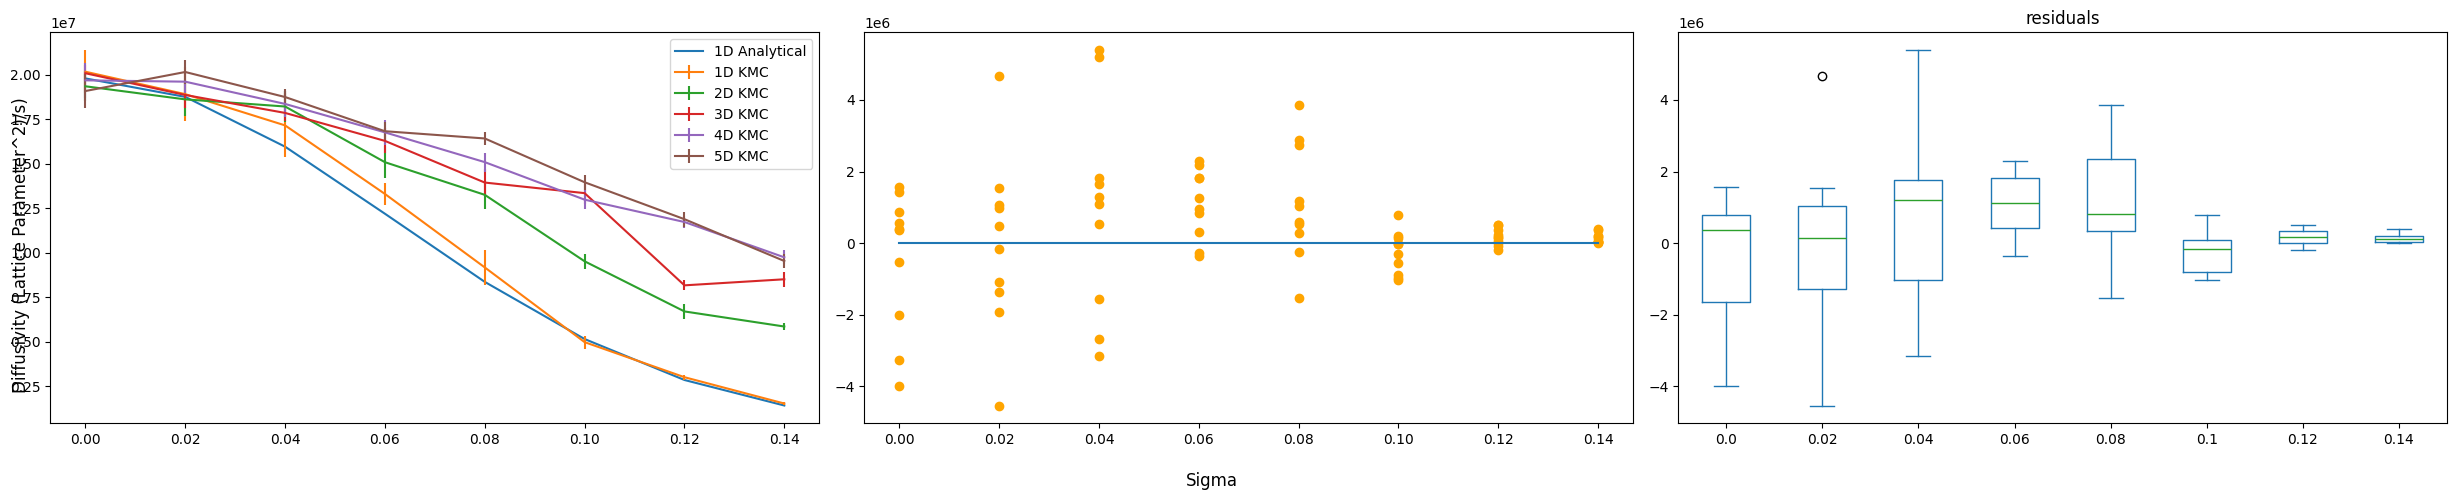

In [95]:
def one_d_analytical(si):
    kT = physical_constants['Boltzmann constant in eV/K'][0] * 1000
    return np.exp(
        -(saddle_mean-init_mean)/(kT)-
        ((si)**2)/(kT**2)
    ) * 1e13

x_vals = np.sort(list(set(slopes['init_sd'])))
y_vals = np.array([one_d_analytical(x) for x in x_vals])
#y_vals /= y_vals[0]

fig, ax = plt.subplots(1,3, sharex=False, sharey=False, figsize=(25,5))

ax[0].plot(x_vals, y_vals, label='1D Analytical')
for n in set(slopes['n_dim']):
#for n in [1]:
    s = pd.DataFrame(slopes[slopes['n_dim'] == n])
    divisor = np.mean(s[s['init_sd'] == 0.0]['diffusivity'])
    #s['diffusivity'] /= divisor
    s1 = s[['init_sd','diffusivity']].groupby(by=['init_sd'])
    err = (1.96*s1.std())/np.sqrt(s1.count())
    center = s1.mean()
    ax[0].errorbar(center.index,center['diffusivity'], yerr=err['diffusivity'], label=f'{n}D KMC')
    #plt.scatter(s['init_sd'],s['diffusivity'])
    if n != 1:
        continue
    s['residuals'] = s['diffusivity'] - s['init_sd'].map(dict(zip(x_vals, y_vals)))
    s2 = s[['init_sd','residuals']].groupby(by=['init_sd'])
    ax[1].plot(center.index, y_vals-y_vals)
    ax[1].scatter(s['init_sd'], s['residuals'], color='Orange')
    s.plot.box(column='residuals', by='init_sd', ax=ax[2],sharex=False)




    #plt.plot(med,label=f'{n}D KMC')

fig.supylabel('Diffusivity (Lattice Parameter^2)/s)')
fig.supxlabel('Sigma')
ax[0].legend()
plt.tight_layout()

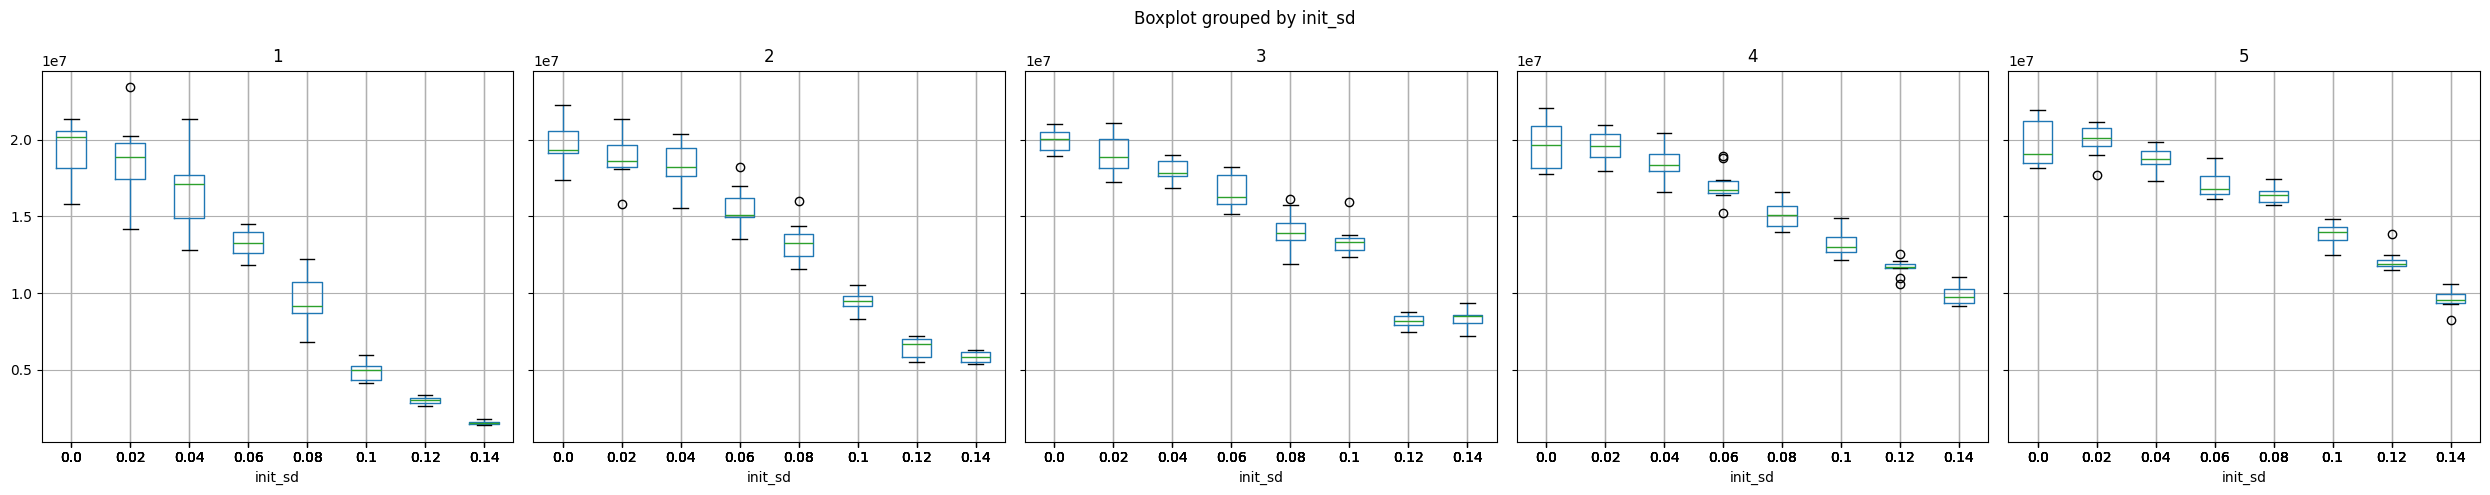

In [90]:
slopes.groupby('n_dim').boxplot(column='diffusivity', by='init_sd', figsize=(25,5),layout=(1,5), sharey=True, sharex=True)
plt.tight_layout()